# Presynaptic-derived TEASAR skeleton statistics: components with >5 presynaptic sites

Every analysis below uses the larger `presynaptic_axons/k10` dataset (2,209 cells), restricted to connected components with **more than five unique accepted presynaptic site IDs**, after the existing 5 µm soma cut. Stored site mappings must be within 2 µm; duplicate rows count once. All edges in each qualifying component are retained. This is a component filter, not an axon classifier.

The same population is used for the summary, pooled fits, cell-type distributions, and upstream branch/synapse plots. Upstream plots additionally retain the existing requirement of a tree with exactly one cut-boundary root. Fits and plots use the central 99% of positive finite retained edge lengths.

Filtered lengths, summary statistics, quantile bounds, and upstream histograms are cached on disk. Source file paths, sizes, and modification times determine cache identity; changing the source creates a new cache. Restart the kernel and Run All after updating this notebook to replace old in-memory unfiltered variables.


In [1]:
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import importlib

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "gnn").is_dir())
while not (ROOT / 'gnn').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
ANALYSIS_DIR = ROOT / 'analysis' / 'presynaptic' / 'new_skeletons'
if str(ANALYSIS_DIR) in sys.path:
    sys.path.remove(str(ANALYSIS_DIR))
sys.path.insert(0, str(ANALYSIS_DIR))

# Refresh edited helper code even when this kernel has imported it before.
cached_helper = sys.modules.get("skeleton_stats")
if cached_helper is not None and Path(cached_helper.__file__).resolve() != (ANALYSIS_DIR / "skeleton_stats.py").resolve():
    del sys.modules["skeleton_stats"]
import filtered_stats as skeleton_stats
importlib.reload(skeleton_stats)
print(f"Stats helper: {skeleton_stats.__file__}")

from filtered_stats import (
    PRESYNAPTIC_DATABASE, GMM_COMPONENTS, PLOT_PERCENTILES, load_presynaptic_lengths,
    parameter_table, plot_distribution_and_gmm, streaming_quantiles, summarize,
)

# Component count is chosen explicitly; the fitter does not infer it.
N_COMPONENTS = 3

presynaptic_lengths = load_presynaptic_lengths()
print(f'Presynaptic database: {PRESYNAPTIC_DATABASE}')
print(f'Presynaptic-derived TEASAR edges: {len(presynaptic_lengths):,}')

Stats helper: /orcd/home/002/jcbliao/rotation/segclr/gnn_classifier/analysis/presynaptic/new_skeletons/filtered_stats.py
>5-site components: 136,241,017 / 149,925,558 edges; 2,209 cells (persistent cache)


Presynaptic database: /orcd/scratch/orcd/013/jcbliao/presynaptic_axons/k10
Presynaptic-derived TEASAR edges: 136,241,017


## Untrimmed summary of retained components

Summary covers all positive finite edges in components with >5 sites. The first calculation scans the retained array several times; subsequent calls load the cached summary. `.round(2)` and `display` only operate on the small summary table. Percentile trimming applies only to plots and fits.


In [2]:
summary = summarize(presynaptic_lengths)
display(summary.round(2))

,edges,mean_nm,std_nm,p1_nm,p5_nm,p25_nm,p50_nm,p75_nm,p95_nm,p99_nm
Presynaptic-derived TEASAR,136241017,162.32,247.13,81.32,91.21,107.74,126.01,193.6,333.17,466.37


## Edge-length probability mass and Gaussian mixtures

The logarithmic plot uses geometrically spaced edge-length bins and a Gaussian mixture fitted to `log10(edge length)`. The linear plot uses equal-width nanometer bins and a Gaussian mixture fitted directly in nanometers. Component curves include their mixture weights; the black curve is their sum. Fits still use the central 99% population; the outermost 1% is excluded from fitting as well as display. Each observed PMF and fitted mixture sums to one over the displayed range.

Displayed range: 77.62–531.71 nm (0.5th–99.5th percentiles)
Building histogram and mixture fit (cached after this run)


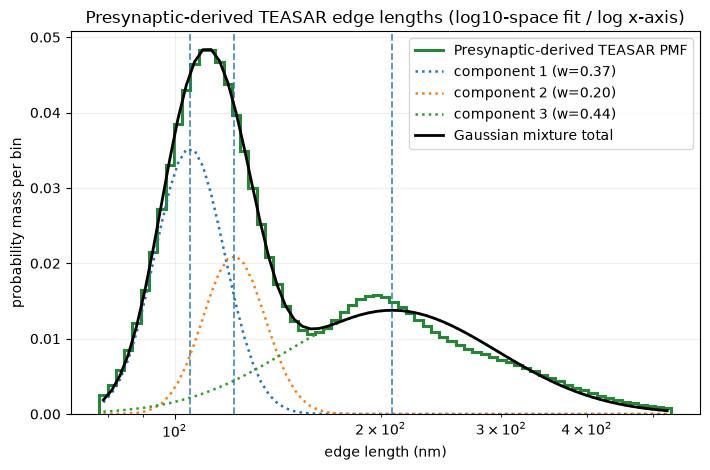

In [3]:
bounds = streaming_quantiles(presynaptic_lengths, PLOT_PERCENTILES, log_bins=True)
print(f'Displayed range: {bounds[0]:,.2f}–{bounds[1]:,.2f} nm '      f'({PLOT_PERCENTILES[0]}th–{PLOT_PERCENTILES[1]}th percentiles)')

log_figure, log_model = plot_distribution_and_gmm(
    presynaptic_lengths, bounds, log_space=True, n_components=N_COMPONENTS,
    family="Gaussian", compare_gaussian=False
)
plt.close(log_figure)  # Display once via the final expression.
log_figure


Building histogram and mixture fit (cached after this run)


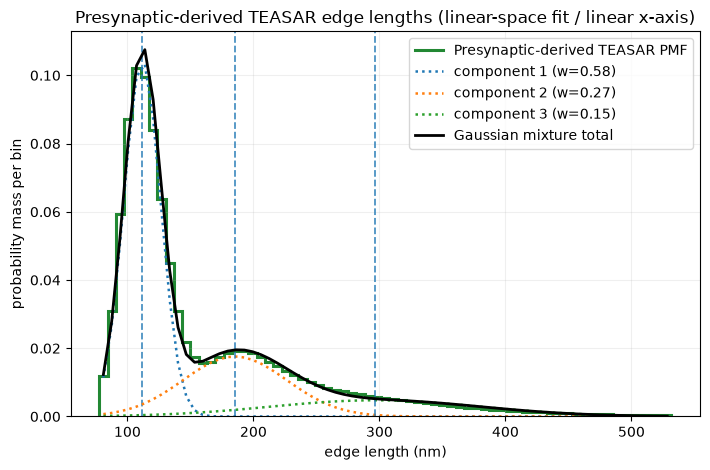

In [4]:
linear_figure, linear_model = plot_distribution_and_gmm(
    presynaptic_lengths, bounds, log_space=False, n_components=N_COMPONENTS,
    family="Gaussian", compare_gaussian=False
)
plt.close(linear_figure)  # Display once via the final expression.
linear_figure


## Mixture parameters

For the log10 fit, `location_fit_units` and `scale_fit_units` are in log10(nm); `component_center_nm` transforms the component location back to nanometers. Linear-fit values are directly in nanometers. Gaussian locations are component means and scales are standard deviations in the fitted space. The log-space fit corresponds to a mixture of lognormal distributions in nanometers. The component count is explicitly set by `N_COMPONENTS = 3`; it is not selected automatically.

In [5]:
display(parameter_table(log_model, linear_model).round(4))

,fit_space,component,weight,family,location_fit_units,scale_fit_units,component_center_nm,iterations
0,log10,1,0.3675,Gaussian,2.0224,0.0504,105.2831,200
1,log10,2,0.1972,Gaussian,2.0869,0.0454,122.1619,200
2,log10,3,0.4353,Gaussian,2.3179,0.1534,207.8988,200
3,linear,1,0.5768,Gaussian,111.6844,14.5049,111.6844,94
4,linear,2,0.2734,Gaussian,185.3211,41.1086,185.3211,94
5,linear,3,0.1498,Gaussian,296.7896,83.3601,296.7896,94


## Edge-length distributions by cell type

These empirical distributions use the same presynaptic-derived skeleton edges, grouped by `cell_type` in `data/manifest.json`. Each type is normalized separately within the same pooled percentile bounds used above. Edges are pooled across cells (so larger skeletons contribute more edges), with each edge counted once per cell. Each cell type has its own panel in a K × 5 grid, using identical linear bins and shared x- and y-axis limits, with no mixture fits. Missing labels appear as `Unlabeled`; the table reports cell and edge counts, including types with no edges inside the displayed range.


,cell_type,cells,positive_finite_edges,displayed_edges
0,AltBasket,34,2161325,2148046
1,AltDTC,9,366867,363220
2,DTC,16,1210964,1201407
3,ITC,71,2936494,2909425
4,ITCperi,18,677615,672735
5,L1,13,639200,634211
6,L2IT,346,19364267,19125271
7,L3IT,245,13738128,13601142
8,L4IT,546,30020031,29785406
9,L5ET,58,2668188,2563257


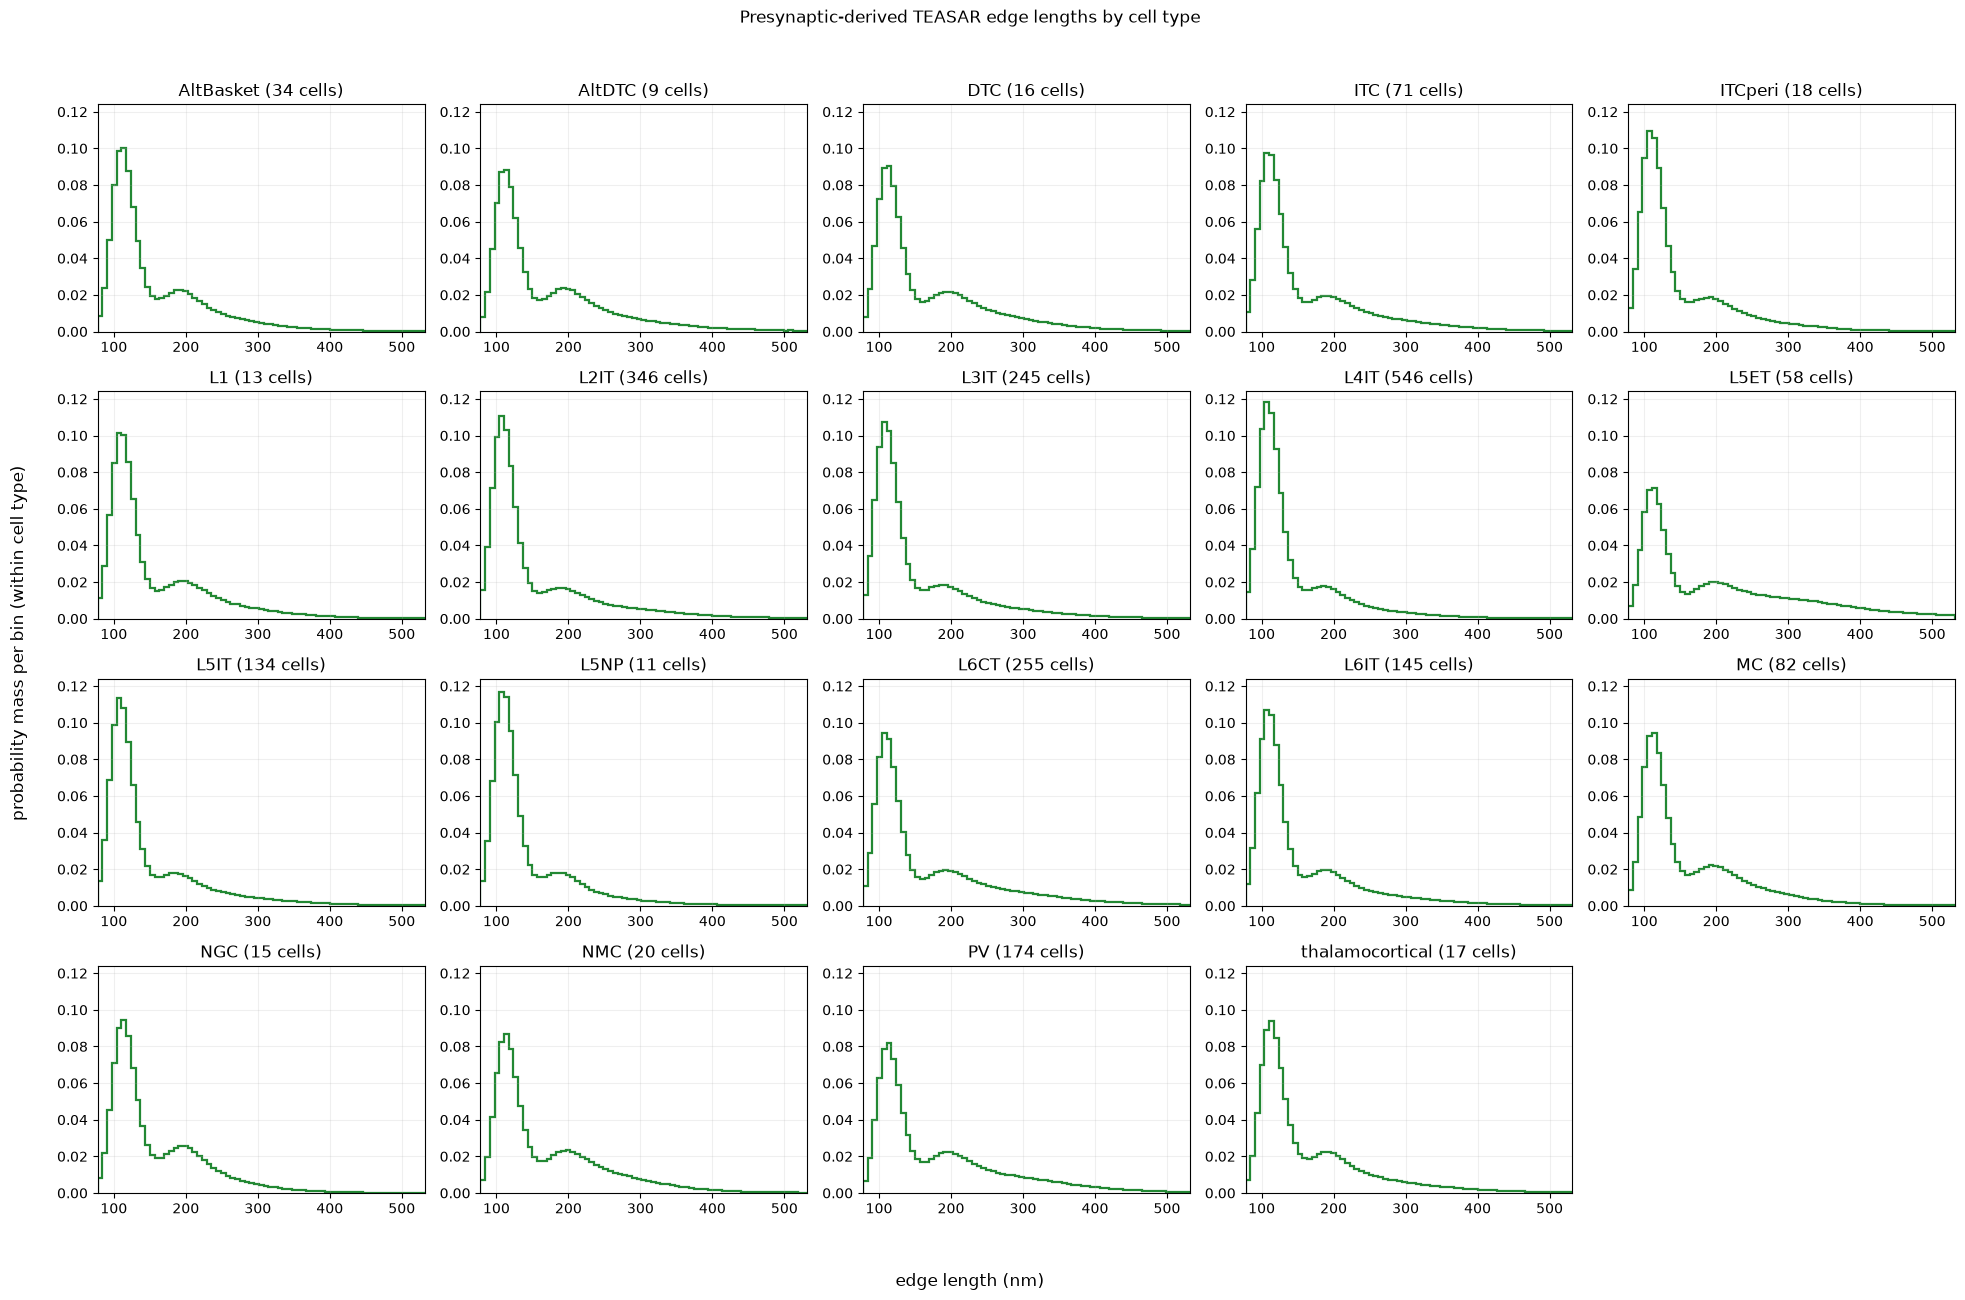

In [6]:
# Reload the helper so this section also works in an existing kernel.
importlib.reload(skeleton_stats)
cell_type_figure, cell_type_counts = skeleton_stats.plot_distributions_by_cell_type(
    bounds, database=PRESYNAPTIC_DATABASE, manifest=ROOT / "data" / "manifest.json"
)
display(cell_type_counts)
plt.close(cell_type_figure)  # Display once via the final expression.
cell_type_figure


## Edge length versus upstream branch points and synapses

Trees are oriented away from the surviving cut-adjacent root, recovered by reconstructing and verifying the soma cut against the original skeleton. For each edge, counts cover the **path from the root through the edge's proximal (upstream) endpoint**, including that endpoint and excluding the distal endpoint:

- **Upstream branch points:** non-root nodes with two or more children along that path. The cut root is branch point zero, so edges leaving it have count 0 even if it branches. An edge entering the first non-root branch point has count 0; edges leaving that branch point have count 1.
- **Upstream synapses:** unique presynaptic-site IDs mapped to nodes along that path, including sites on the cut root. Sites in sibling branches and at the distal endpoint are excluded. We use the database's `new_nearest_observed_node` mappings accepted by `new_within_2um`, without requiring `new_valid_k_window`. Distinct sites on the same node all count.

Components with no cut-adjacent root, multiple candidate roots, or cycles are excluded and reported. Unmatched sites and sites on excluded components are also reported. Each eligible edge contributes once; counts do not include erased soma-region nodes.

Both metrics are computed in one parallel pass with compiled graph orientation and path summation. Exact histograms are stored sparsely. Plots use linear axes, the same edge-length bounds as above, and at most 200 equal-width x bins (the count width is labeled). No edges are sampled. Color shows edge count on a logarithmic scale. Each metric has a pooled plot and a K × 5 cell-type grid with shared bounds and color scale. Change `UPSTREAM_WORKERS` to control concurrency; replotting `upstream_length_data` does not repeat collection.


In [7]:
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import importlib

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "gnn").is_dir())
while not (ROOT / 'gnn').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
ANALYSIS_DIR = ROOT / 'analysis' / 'presynaptic' / 'new_skeletons'
if str(ANALYSIS_DIR) in sys.path:
    sys.path.remove(str(ANALYSIS_DIR))
sys.path.insert(0, str(ANALYSIS_DIR))

# Refresh edited helper code even when this kernel has imported it before.
cached_helper = sys.modules.get("skeleton_stats")
if cached_helper is not None and Path(cached_helper.__file__).resolve() != (ANALYSIS_DIR / "skeleton_stats.py").resolve():
    del sys.modules["skeleton_stats"]
import filtered_stats as skeleton_stats
importlib.reload(skeleton_stats)
print(f"Stats helper: {skeleton_stats.__file__}")

# Always establish the filtered population, even when running this section alone.
PRESYNAPTIC_DATABASE = skeleton_stats.PRESYNAPTIC_DATABASE
presynaptic_lengths = skeleton_stats.load_presynaptic_lengths(PRESYNAPTIC_DATABASE)
bounds = skeleton_stats.streaming_quantiles(presynaptic_lengths, skeleton_stats.PLOT_PERCENTILES)
print(f"Displayed range: {bounds[0]:,.2f}–{bounds[1]:,.2f} nm")

# None uses up to 4 allocated CPUs; set 1 for serial execution.
UPSTREAM_WORKERS = None
upstream_length_data = skeleton_stats.collect_upstream_length_histograms(
    bounds, database=PRESYNAPTIC_DATABASE, manifest=ROOT / "data" / "manifest.json",
    workers=UPSTREAM_WORKERS
)
upstream_diagnostics = upstream_length_data["diagnostics"]
display(upstream_diagnostics.groupby("cell_type").sum(numeric_only=True))


Stats helper: /orcd/home/002/jcbliao/rotation/segclr/gnn_classifier/analysis/presynaptic/new_skeletons/filtered_stats.py


>5-site components: 136,241,017 / 149,925,558 edges; 2,209 cells (persistent cache)


Displayed range: 77.62–531.71 nm


Upstream counts: 2,209 cells, 4 worker(s)


Upstream counts: 1/2,209 cells (2.5s, 0.4 cells/s)


...

Upstream counts: 2,000/2,209 cells (39.3s, 50.9 cells/s)


Upstream counts: 2,100/2,209 cells (41.1s, 51.1 cells/s)


Upstream counts: 2,200/2,209 cells (42.9s, 51.3 cells/s)


Upstream counts: 2,209/2,209 cells (43.1s, 51.3 cells/s)


,components,rooted_tree_components,no_boundary_root_components,multiple_boundary_root_components,non_tree_components,excluded_edges,included_edges,synapses_in_rooted_trees,synapses_in_excluded_components,source_presynaptic_site_rows,source_unmatched_presynaptic_site_rows,source_duplicate_matched_site_rows,source_matched_unique_presynaptic_sites,matched_unique_presynaptic_sites,positive_finite_rooted_edges,displayed_edges
cell_type,,,,,,,,,,,,,,,,
AltBasket,85,85,0,0,0,0,2161325,43968,0,45861,1639,0,44222,43968,2161325,2148046
AltDTC,27,26,0,1,0,39458,327409,4392,660,5577,497,0,5080,5052,327409,323932
DTC,60,60,0,0,0,0,1210964,28997,0,31347,2224,0,29123,28997,1210964,1201407
ITC,130,127,0,3,0,34272,2902222,40798,253,45737,4504,0,41233,41051,2902222,2875781
ITCperi,28,26,0,2,0,61792,615823,10605,1002,12772,1097,0,11675,11607,615823,611422
L1,26,25,0,1,0,13049,626151,17366,541,19226,1260,0,17966,17907,626151,621258
L2IT,874,834,0,40,0,1132179,18232088,137019,6914,158205,11577,0,146628,143933,18232088,18009150
L3IT,561,547,0,14,0,333954,13404174,131426,3204,148598,11855,0,136743,134630,13404174,13271875
L4IT,1100,1056,0,44,0,1315740,28704291,325251,14378,373910,30872,0,343038,339629,28704291,28481300


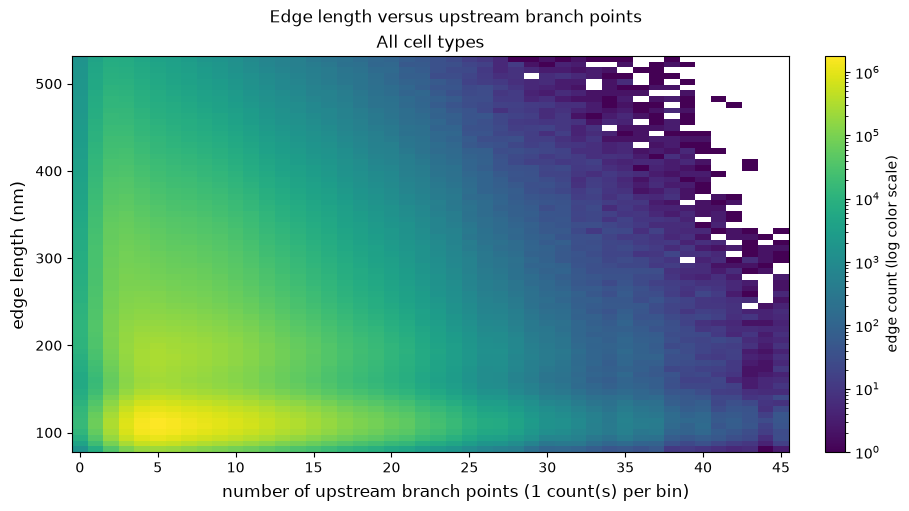

In [8]:
upstream_branch_figure = skeleton_stats.plot_edge_length_by_upstream_count(
    upstream_length_data, metric="branches"
)
plt.close(upstream_branch_figure)  # Display once via the final expression.
upstream_branch_figure


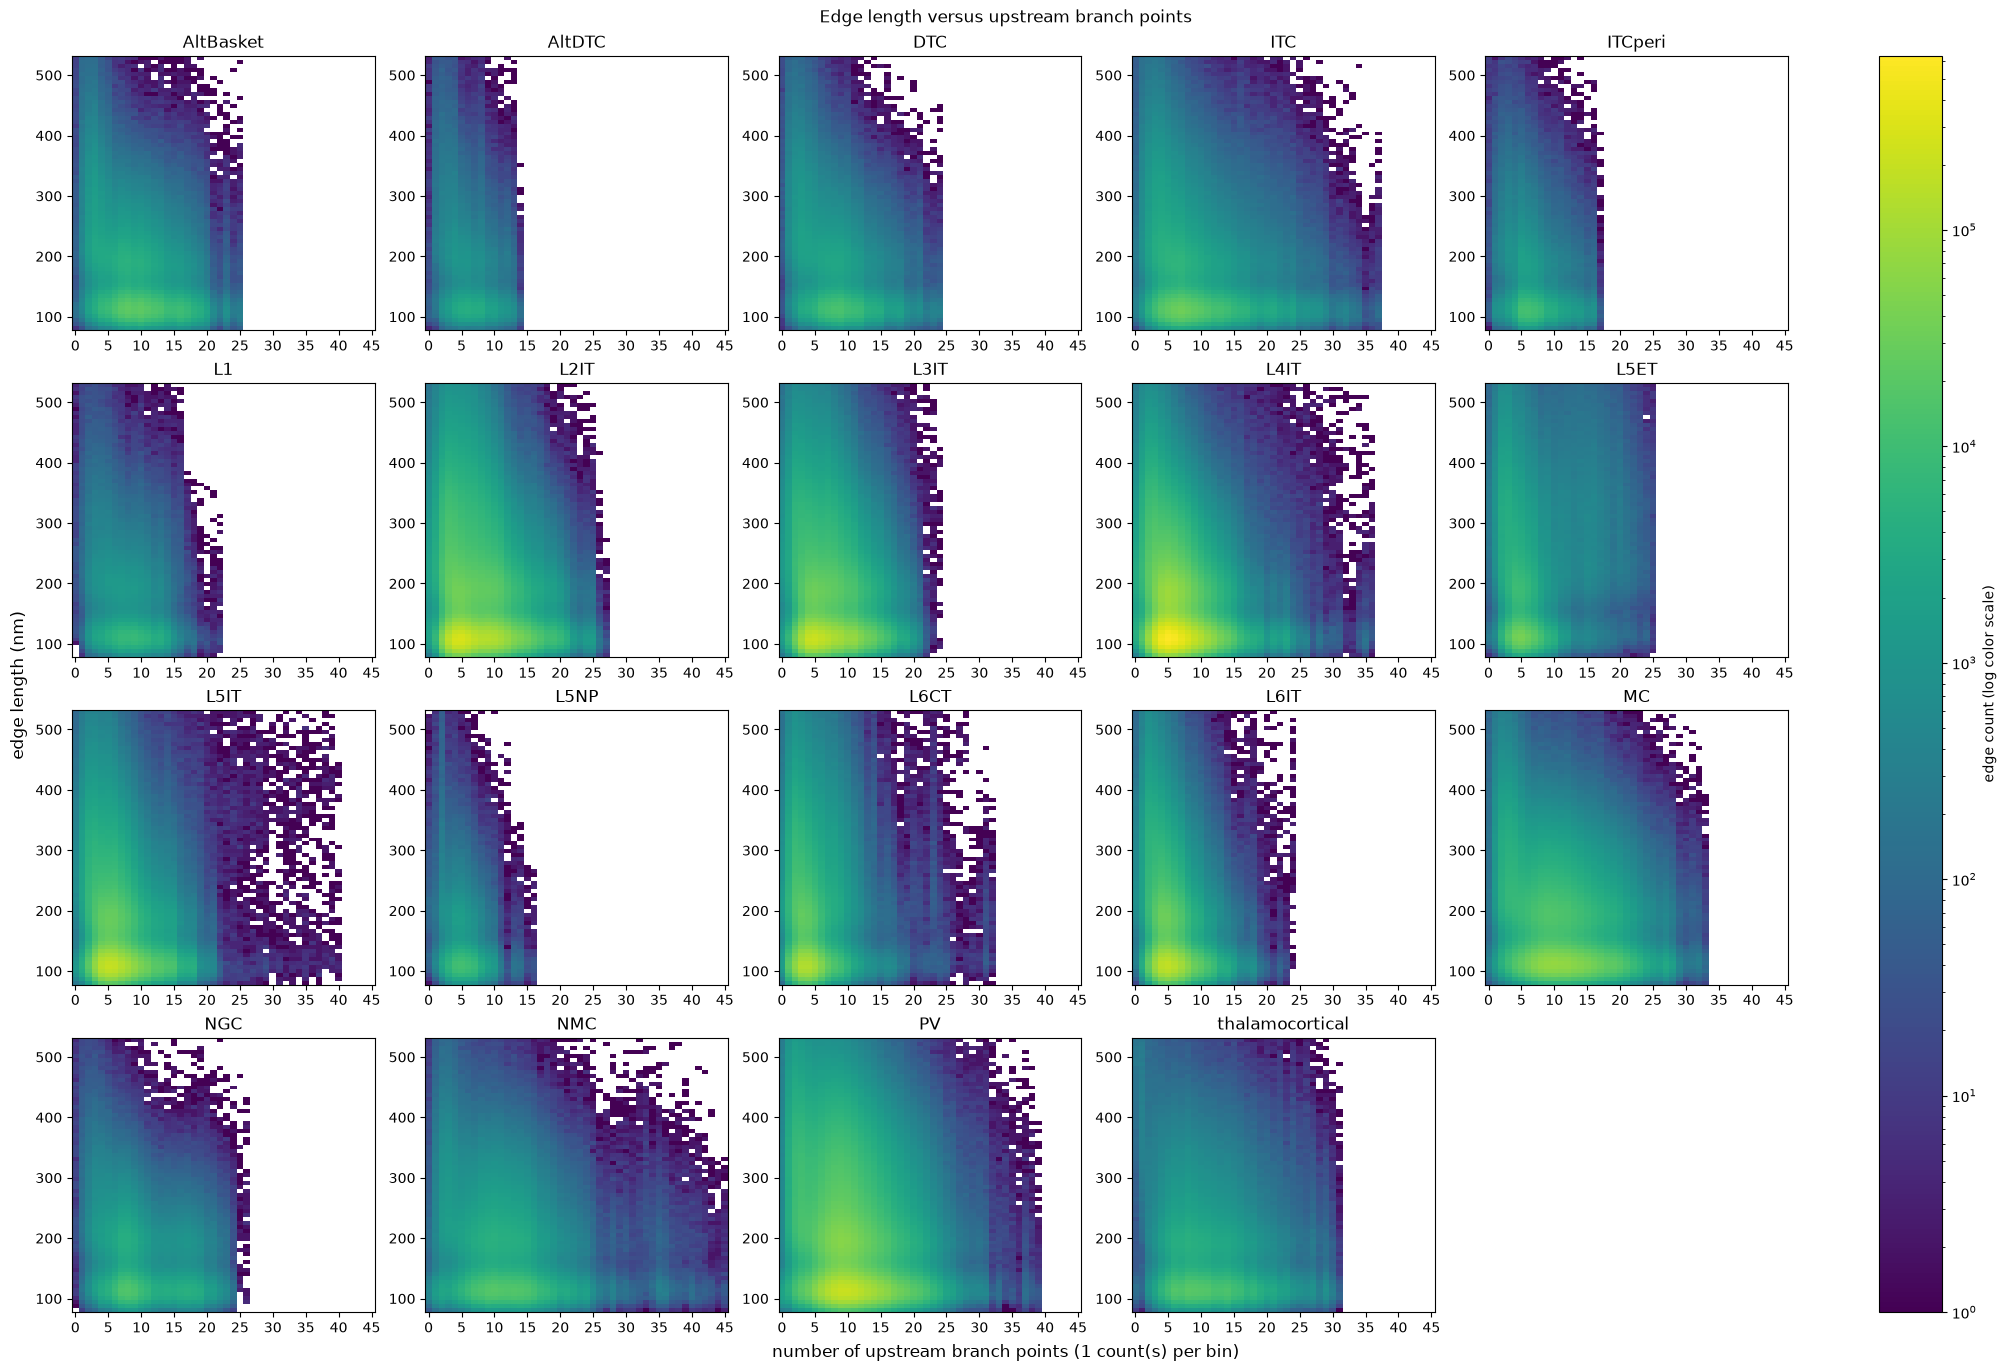

In [9]:
upstream_branch_cell_type_figure = skeleton_stats.plot_edge_length_by_upstream_count(
    upstream_length_data, metric="branches", by_cell_type=True
)
plt.close(upstream_branch_cell_type_figure)  # Display once via the final expression.
upstream_branch_cell_type_figure


## Edge length versus upstream presynaptic sites


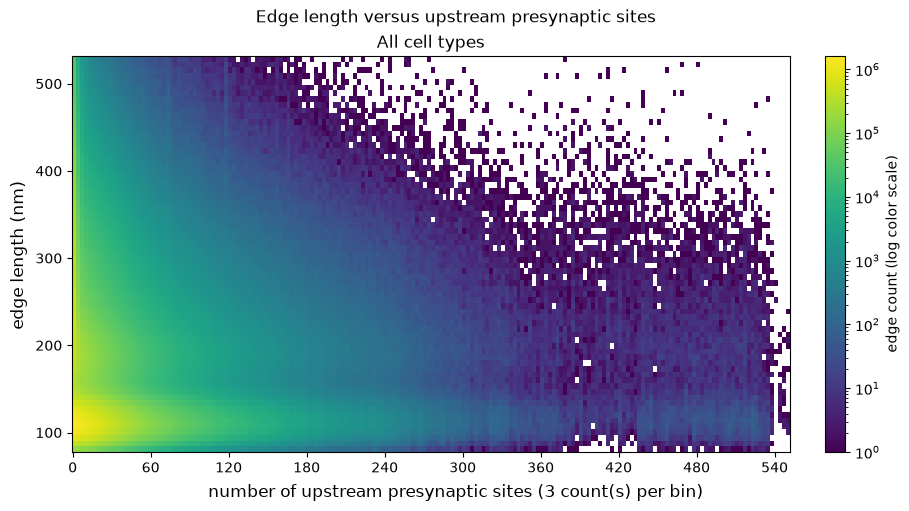

In [10]:
upstream_synapse_figure = skeleton_stats.plot_edge_length_by_upstream_count(
    upstream_length_data, metric="synapses"
)
plt.close(upstream_synapse_figure)  # Display once via the final expression.
upstream_synapse_figure


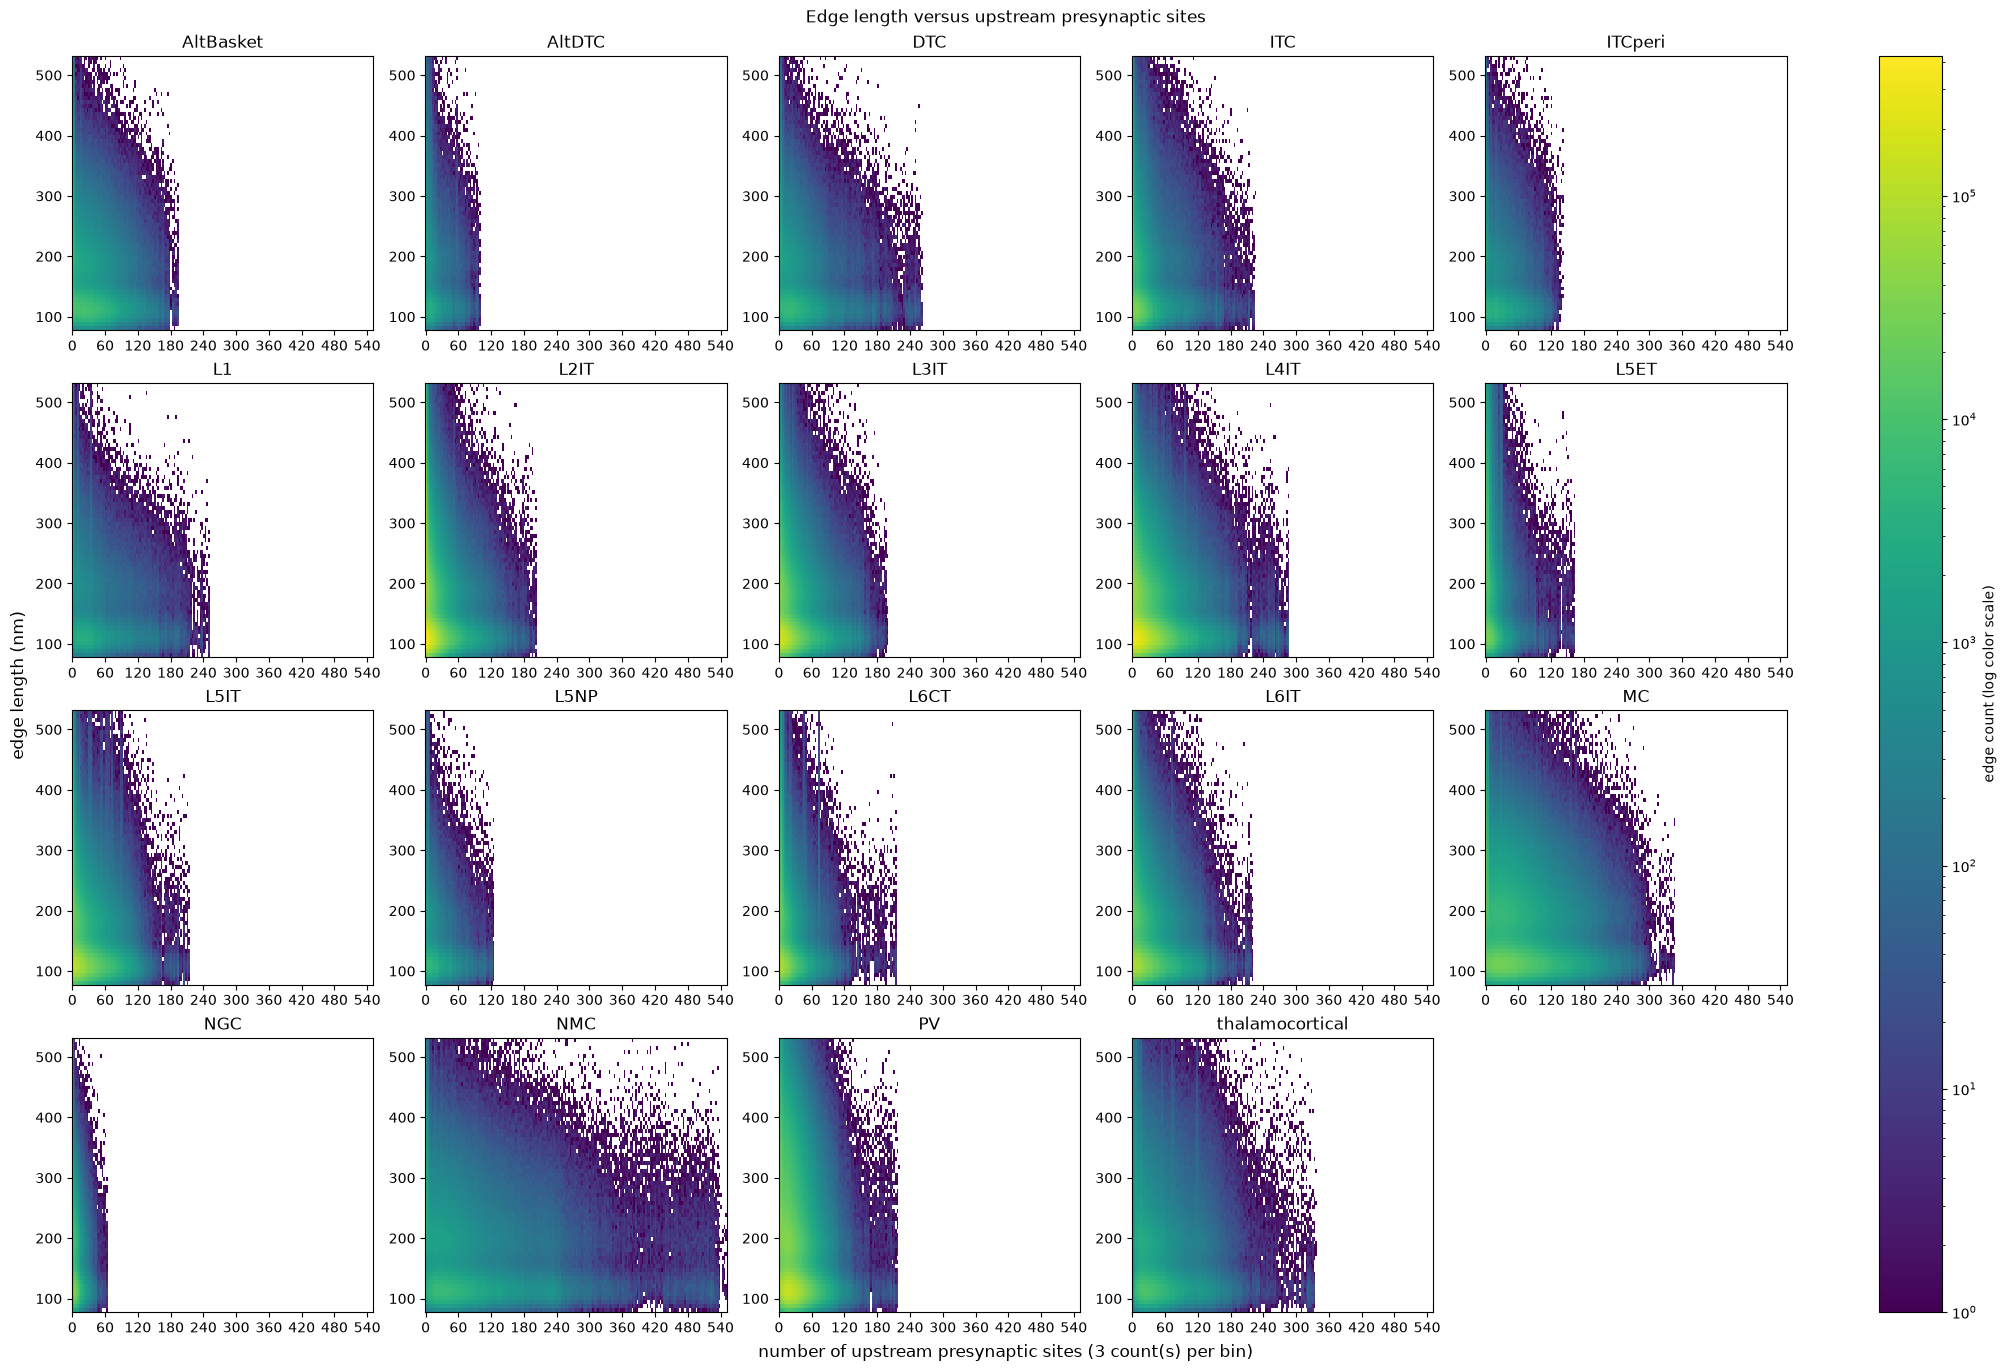

In [11]:
upstream_synapse_cell_type_figure = skeleton_stats.plot_edge_length_by_upstream_count(
    upstream_length_data, metric="synapses", by_cell_type=True
)
plt.close(upstream_synapse_cell_type_figure)  # Display once via the final expression.
upstream_synapse_cell_type_figure


## Presynaptic sites per connected component — before the >5 filter

Here **component means an undirected connected component after the 5 µm soma
cut**, including isolated nodes. This cutoff-diagnostic section deliberately
includes **all components, including zero-site components**, before either the
>5-site filter or upstream root/tree exclusions. It does not change the filter
used by the preceding analyses.

Count distinct presynaptic IDs mapped within 2 µm, using each dataset's existing
mapping: non-native to a mapped SegCLR-bearing node, native directly to a
resampled node. Components are counted once each and pooled across the same
2,209 cells. The histograms cover the complete range, including zero-site components,
using equal-width 100-site bins and linear axes. Heights are component counts
per bin. Change HISTOGRAM_BIN_WIDTH in the cell to adjust the bin width; the
range always extends through the maximum observed count. The retention curves apply **strictly >k sites**.

Loading cached connected-component site counts


,cells,components,zero_site_components,one_to_five_components,components_gt5,median_sites,p90_sites,p99_sites,max_sites
dataset,,,,,,,,,
Non-native,2209,16657,4402,6816,5439,2.0,280.0,3352.40,14557
Native resampled,2209,16765,3682,7253,5830,3.0,284.6,3413.96,14999


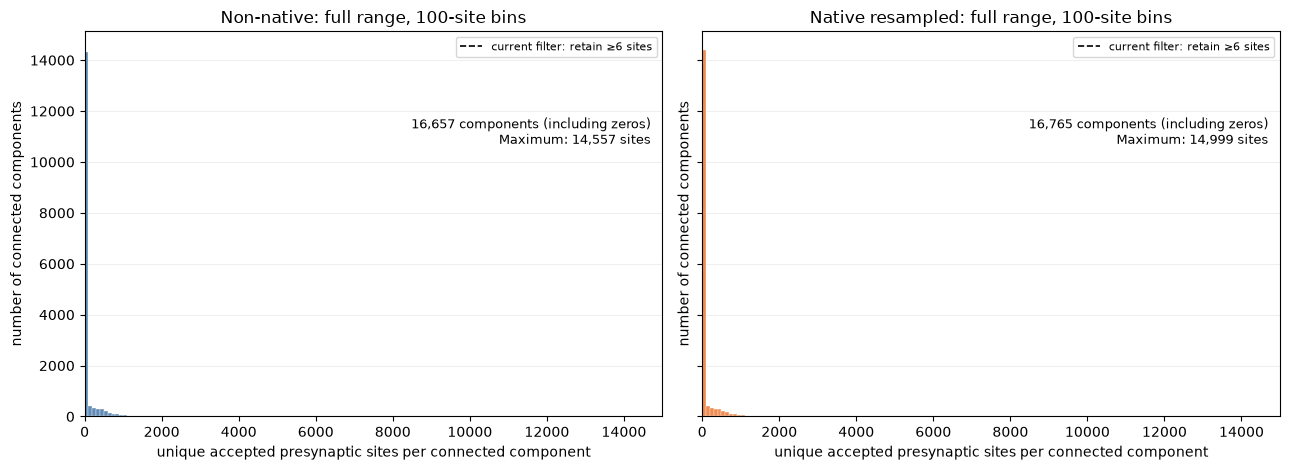

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'gnn').is_dir())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from analysis.presynaptic.component_site_distribution import component_site_counts
component_counts = component_site_counts.load_components()
display(component_site_counts.summary_table(component_counts))
HISTOGRAM_BIN_WIDTH = 100
component_distribution_figure = component_site_counts.plot_distribution(
    component_counts, bin_width=HISTOGRAM_BIN_WIDTH
)
plt.close(component_distribution_figure)
component_distribution_figure

,dataset,cutoff,retained_components,retained_component_fraction,retained_edges,retained_edge_fraction
0,Non-native,0,12255,0.7357,147521622,0.9840
1,Non-native,1,9819,0.5895,144509974,0.9639
2,Non-native,2,8038,0.4826,141758380,0.9455
3,Non-native,5,5439,0.3265,136241017,0.9087
4,Non-native,10,4107,0.2466,131862959,0.8795
5,Non-native,20,3458,0.2076,129039398,0.8607
6,Non-native,50,2759,0.1656,125373757,0.8362
7,Non-native,100,2328,0.1398,121589156,0.8110
8,Non-native,200,1924,0.1155,114843892,0.7660
9,Non-native,500,1013,0.0608,80797720,0.5389


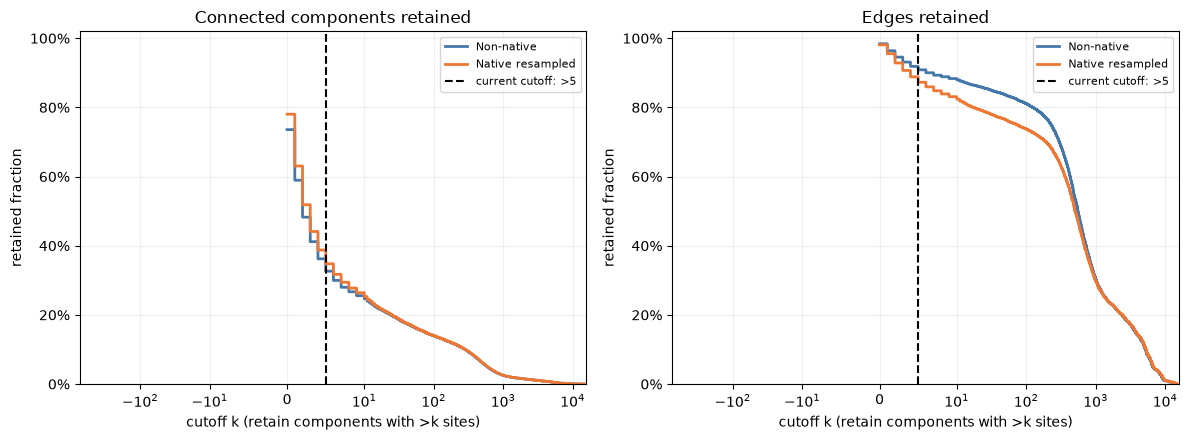

In [2]:
display(component_site_counts.cutoff_table(component_counts).round(4))
component_retention_figure = component_site_counts.plot_cutoff_retention(component_counts)
plt.close(component_retention_figure)
component_retention_figure